<a href="https://colab.research.google.com/github/jingxuchen19/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/Class%2015/Lab_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

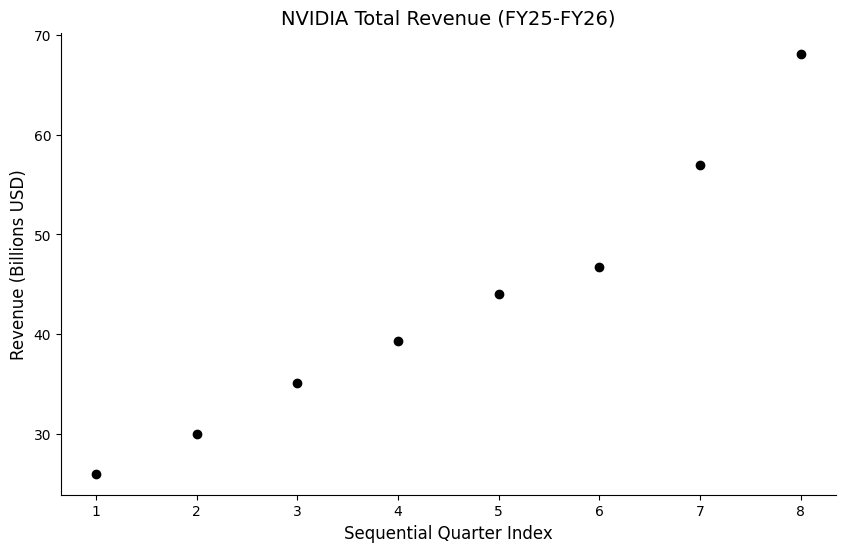

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score

# Step 1: Ingestion of Modernized NVIDIA Dataset
# Data reflects the massive AI infrastructure capex boom of 2024-2026

data = {
    'Time_Index': np.array([1, 2, 3, 4, 5, 6, 7, 8]),
    'Total_Revenue_Billions': np.array([26.04, 30.04, 35.10, 39.33, 44.06, 46.74, 57.00, 68.10])
}
df = pd.DataFrame(data)

X = df[['Time_Index']]
y = df['Total_Revenue_Billions']

# Visual EDA (Adhering to Data-Ink Ratio principles)
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='black', label='Actual Revenue')
plt.title('NVIDIA Total Revenue (FY25-FY26)', fontsize=14)
plt.xlabel('Sequential Quarter Index', fontsize=12)
plt.ylabel('Revenue (Billions USD)', fontsize=12)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

Linear Training MSE (High Bias): 7.91


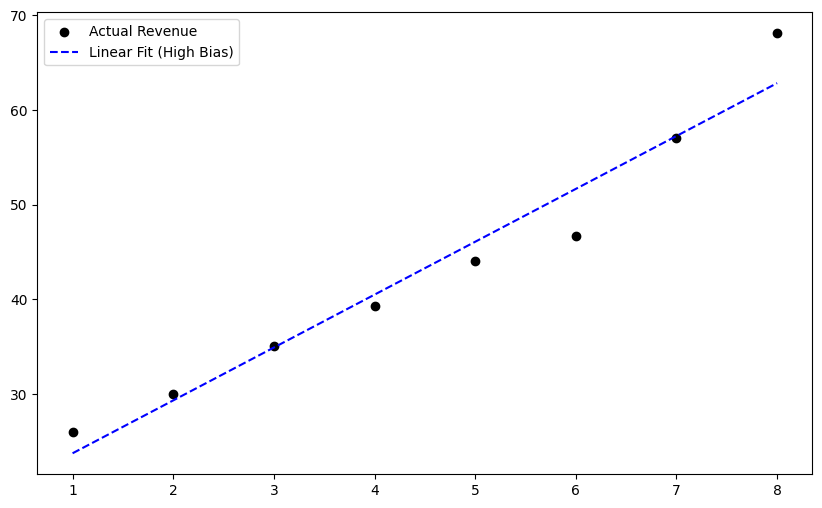

In [27]:
# Step 2: High Bias (Underfitting) Linear Model
lin_reg = LinearRegression()
lin_reg.fit(X, y)
y_pred_linear = lin_reg.predict(X)
mse_linear = mean_squared_error(y, y_pred_linear)

print(f"Linear Training MSE (High Bias): {mse_linear:.2f}")

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='black', label='Actual Revenue')
plt.plot(X, y_pred_linear, color='blue', linestyle='--', label='Linear Fit (High Bias)')
plt.legend()
plt.show()

Polynomial Degree-7 Training MSE (High Variance): 0.00


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


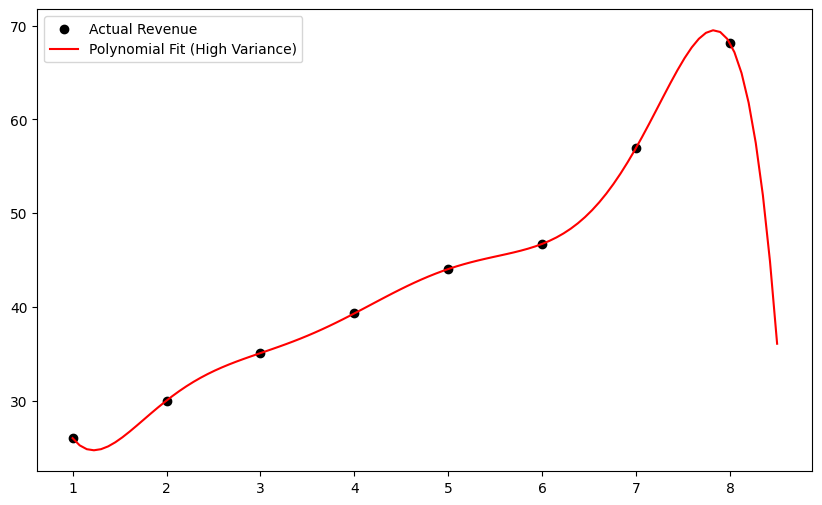

In [28]:
# Step 3: High Variance (Overfitting) Polynomial Model
poly_features = PolynomialFeatures(degree=7, include_bias=False)
X_poly = poly_features.fit_transform(X)

poly_reg = LinearRegression()
poly_reg.fit(X_poly, y)
y_pred_poly = poly_reg.predict(X_poly)
mse_poly = mean_squared_error(y, y_pred_poly)

print(f"Polynomial Degree-7 Training MSE (High Variance): {mse_poly:.2f}")

# Plotting the smooth polynomial curve
X_smooth = np.linspace(1, 8.5, 100).reshape(-1, 1)
X_smooth_poly = poly_features.transform(X_smooth)
y_smooth_poly = poly_reg.predict(X_smooth_poly)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='black', label='Actual Revenue')
plt.plot(X_smooth, y_smooth_poly, color='red', label='Polynomial Fit (High Variance)')
plt.legend()
plt.show()

In [29]:
# Step 4: The Extrapolation Collapse
X_future = np.array([[9]])  # Forecasting Q1 FY27
X_future_poly = poly_features.transform(X_future)
future_pred = poly_reg.predict(X_future_poly)

print(f"\nHallucinated Q1 FY27 Revenue Prediction: ${future_pred[0]:.2f} Billion")


Hallucinated Q1 FY27 Revenue Prediction: $-84.00 Billion


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [30]:
# Step 5: K-Fold Cross Validation
cv_scores = cross_val_score(poly_reg, X_poly, y, cv=4, scoring='neg_mean_squared_error')
mean_cv_mse = -cv_scores.mean()

print(f"K-Fold Cross-Validated MSE (The True Operational Error): {mean_cv_mse:.2f}")

K-Fold Cross-Validated MSE (The True Operational Error): 8641.58


Optimal Alpha (λ) selected by 4-Fold CV: 17.0735
Ridge Training MSE: 0.26
Ridge K-Fold Cross-Validated MSE: 4897.44

── Coefficient Comparison ──
Degree     OLS (Overfit)        Ridge (Regularized) 
--------------------------------------------------
x^1       -256.4349            0.0387              
x^2       249.2455             0.1113              
x^3       -121.3472            0.2183              
x^4       33.0058              0.2509              
x^5       -5.0644              -0.1245             
x^6       0.4087               0.0185              
x^7       -0.0134              -0.0009             


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


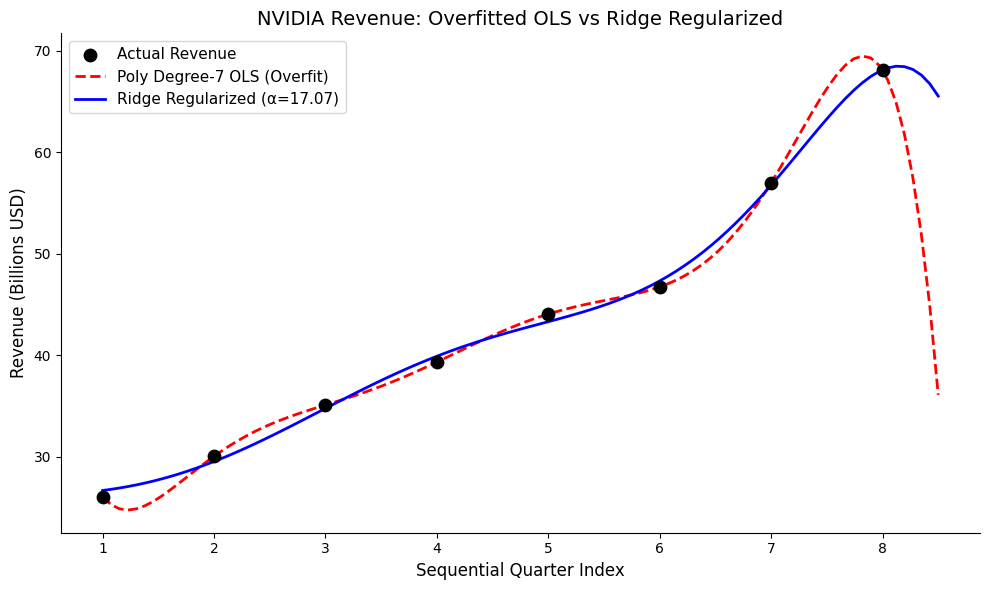


══ FINAL COMPARISON ══
Metric                              OLS Poly-7         Ridge Poly-7      
Training MSE                        0.00               0.26              
K-Fold CV MSE (True Error)          8641.58            4897.44           
Variance Gap (CV - Train)           8641.58            4897.19           


In [31]:
# ══════════════════════════════════════════════════════════════════════
# AI-ASSISTED EXPANSION: Ridge Regression (L2 Regularization)
# Goal: Constrain the chaotic variance of the 7th-degree polynomial
#        by penalizing large coefficient weights.
# ══════════════════════════════════════════════════════════════════════

from sklearn.linear_model import RidgeCV

# ── Step 1: Define a range of candidate alpha (λ) values ─────────────
# Alpha controls the L2 penalty strength:
#   - Small alpha ≈ no penalty (behaves like OLS, high variance)
#   - Large alpha = heavy penalty (shrinks coefficients toward zero, more stable)
alphas = np.logspace(-2, 6, 100)  # 100 candidates from 0.01 to 1,000,000

# ── Step 2: Use RidgeCV with 4-Fold Cross-Validation ─────────────────
# RidgeCV automatically tests every alpha using 4-Fold CV and picks
# the one with the lowest cross-validated error.
# Under the hood, for EACH alpha candidate:
#   Ridge minimizes: SSE + alpha * Σ(β_j²)
#   The α * Σ(β_j²) term is the L2 penalty — it adds a "tax" on large
#   coefficients, forcing the optimizer to keep weights small and stable.
ridge_cv = RidgeCV(alphas=alphas, cv=4, scoring='neg_mean_squared_error')

# Fit on the SAME 7th-degree polynomial features from Step 3
# X_poly was already created by PolynomialFeatures(degree=7)
ridge_cv.fit(X_poly, y)

# ── Step 3: Extract the optimal alpha and results ────────────────────
best_alpha = ridge_cv.alpha_
print(f"Optimal Alpha (λ) selected by 4-Fold CV: {best_alpha:.4f}")

# Ridge predictions on training data
y_pred_ridge = ridge_cv.predict(X_poly)
mse_ridge_train = mean_squared_error(y, y_pred_ridge)
print(f"Ridge Training MSE: {mse_ridge_train:.2f}")

# ── Step 4: Cross-Validated MSE for the Ridge model ──────────────────
# This is the TRUE out-of-sample error — the metric that actually matters.
cv_scores_ridge = cross_val_score(
    ridge_cv, X_poly, y, cv=4, scoring='neg_mean_squared_error'
)
mean_cv_mse_ridge = -cv_scores_ridge.mean()
print(f"Ridge K-Fold Cross-Validated MSE: {mean_cv_mse_ridge:.2f}")

# ── Step 5: Compare coefficient magnitudes ───────────────────────────
# The L2 penalty explicitly shrinks coefficient weights:
#   Without penalty (OLS), the optimizer is free to assign huge weights
#   to perfectly memorize every data point — this is overfitting.
#   With L2 penalty, every coefficient β_j is "taxed" proportionally to β_j².
#   Larger weights get taxed MORE (because squaring amplifies big values),
#   so the optimizer is forced to find a solution with smaller, more
#   moderate weights — this suppresses chaotic variance.
print("\n── Coefficient Comparison ──")
print(f"{'Degree':<10} {'OLS (Overfit)':<20} {'Ridge (Regularized)':<20}")
print("-" * 50)
for i in range(len(poly_reg.coef_)):
    print(f"x^{i+1:<7} {poly_reg.coef_[i]:<20.4f} {ridge_cv.coef_[i]:<20.4f}")

# ── Step 6: Visualization — Overfitted vs Regularized ────────────────
# Generate smooth curves for both models
X_smooth = np.linspace(1, 8.5, 100).reshape(-1, 1)
X_smooth_poly = poly_features.transform(X_smooth)

y_smooth_ols = poly_reg.predict(X_smooth_poly)       # Original overfit curve
y_smooth_ridge = ridge_cv.predict(X_smooth_poly)      # Ridge regularized curve

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='black', s=80, zorder=5, label='Actual Revenue')
plt.plot(X_smooth, y_smooth_ols, color='red', linewidth=2,
         linestyle='--', label=f'Poly Degree-7 OLS (Overfit)')
plt.plot(X_smooth, y_smooth_ridge, color='blue', linewidth=2,
         label=f'Ridge Regularized (α={best_alpha:.2f})')
plt.title('NVIDIA Revenue: Overfitted OLS vs Ridge Regularized', fontsize=14)
plt.xlabel('Sequential Quarter Index', fontsize=12)
plt.ylabel('Revenue (Billions USD)', fontsize=12)
plt.legend(fontsize=11)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# ── Step 7: Summary comparison ───────────────────────────────────────
print("\n══ FINAL COMPARISON ══")
print(f"{'Metric':<35} {'OLS Poly-7':<18} {'Ridge Poly-7':<18}")
print("=" * 70)
print(f"{'Training MSE':<35} {mse_poly:<18.2f} {mse_ridge_train:<18.2f}")
print(f"{'K-Fold CV MSE (True Error)':<35} {mean_cv_mse:<18.2f} {mean_cv_mse_ridge:<18.2f}")
print(f"{'Variance Gap (CV - Train)':<35} {mean_cv_mse - mse_poly:<18.2f} {mean_cv_mse_ridge - mse_ridge_train:<18.2f}")